# 1. Data Preprocessing 🧹

In [19]:
# handling null values
# aggregations if needed
# renaming columns
# one hot encoding if needed

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt

mushrooms = pd.read_csv("mushrooms.csv")
m_cols = mushrooms.columns.tolist()
mushrooms.replace({"stalk-root": "?"}, np.nan, inplace = True)
X = mushrooms.drop(columns = ["class"])
y = mushrooms["class"]


# for col in m_cols:
#     print(mushrooms[col].value_counts())

# print(mushrooms["stalk-root"].isna().sum())
# print(x)
# print(y)

# we found out this vlaue (strange one) in the stalk-root column
# stalk-root
# ?    2480
# we need to replace it with null to be able to impute it using sklearn lib methods

X_t_v, X_test, y_t_v, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y) # Stratify keeps the percentage of each class (poisnonus and eadible) equal in each set (test, validation, and traninig). That is done to protect it from bias.

X_train, X_validation, y_train, y_validation = train_test_split(
    X_t_v,
    y_t_v,
    test_size = 0.25,
    random_state = 42,
    stratify = y_t_v
)

si = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
oe = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1)
le = LabelEncoder()

X_train = si.fit_transform(X_train)
X_validation = si.transform(X_validation)
X_test = si.transform(X_test)

X_train = oe.fit_transform(X_train)
X_validation = oe.transform(X_validation)
X_test = oe.transform(X_test)

y_train = le.fit_transform(y_train)
y_validation = le.transform(y_validation)
y_test = le.transform(y_test)


# 2. Naive Bayes Implementation 🧠
## 2.1 Training 🏋️‍♂️

In [20]:
def fit(X,y):
    classes, counts = np.unique(y, return_counts = True)
    total = 0.0
    for count in counts:
        total += count

    prior_prop_dic = dict(zip(classes, counts / total))
    lp_smoothing_factor = 1.0
    full_data = np.column_stack((X, y))

    likelihood_dic = {}

    for cls in range(2):
        cls_condition = full_data[:, -1] == cls
        cls_data = full_data[cls_condition]
        zcls_feat_num = cls_data.shape[1]

        likelihood_dic[cls] = {}
        for col in range(zcls_feat_num - 1):
            likelihood_dic[cls][col] = {}
            global_cat = np.unique(full_data[:, col])
            n_cat = len(global_cat)
            total_cls_instances = cls_data.shape[0]
            for cat in global_cat:
                cat_count = np.sum(cls_data[:, col] == cat)
                smoothed_prob = (cat_count + lp_smoothing_factor) / (total_cls_instances + (lp_smoothing_factor * n_cat))
                likelihood_dic[cls][col][cat] =  smoothed_prob 
                        
    return prior_prop_dic, likelihood_dic
    

## 2.2 Prediction 🔮

In [21]:
def predict(X, prior, likelihood):
    final_predictions = []
    for row in X:
        zero_cls_prop = np.log(prior[0])
        one_cls_prop = np.log(prior[1])
        for idx, elm in enumerate(row):
            zero_cls_prop += np.log(likelihood[0][idx][elm])
            one_cls_prop += np.log(likelihood[1][idx][elm])

        props = [zero_cls_prop, one_cls_prop]
        final_predictions.append(np.argmax(props))

    return np.array(final_predictions)



# 3. Experiment 0: Baseline 📊

--- Baseline Model Evaluation ---
Accuracy: 0.9427692307692308

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625



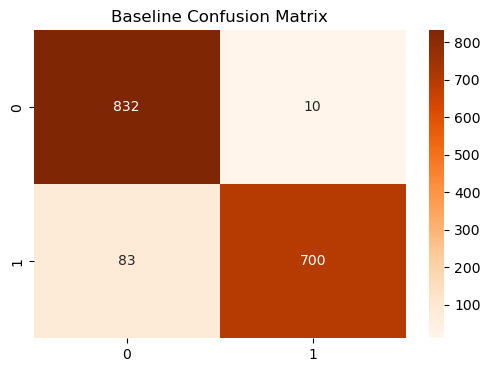

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap
from matplotlib import pyplot as plt

prior, likelihood = fit(X_train, y_train)
predictions = predict(X_validation, prior, likelihood)

print("--- Baseline Model Evaluation ---")
print("Accuracy:", accuracy_score(y_validation, predictions))
print("\nClassification Report:\n", classification_report(y_validation, predictions))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'd', cmap='Oranges')
plt.title("Baseline Confusion Matrix")
plt.show()

# 4. Experiment A: Feature Selection 🎯

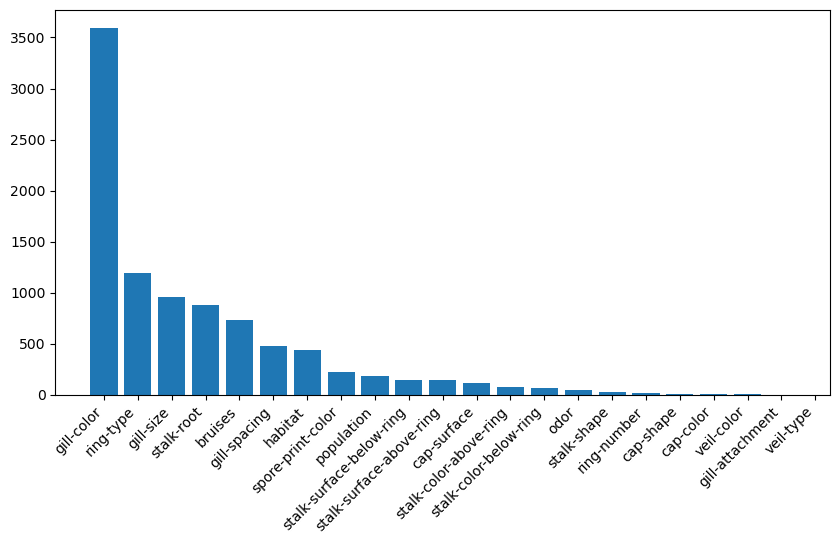

In [23]:
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt
import pandas as pd
sk = SelectKBest(score_func = chi2, k = 22)
X_trial_for_plotting = sk.fit_transform(X_train, y_train)
plt.figure(figsize = (10, 5))
features_scores = pd.Series(data = sk.scores_, index = X.columns).sort_values(ascending = False)
plt.bar(features_scores.index, features_scores.values)
plt.xticks(rotation = 45, ha = 'right')
plt.show()
X_validation = sk.transform(X_validation)
X_test = sk.transform(X_test)

{10: 0.9033846153846153, 11: 0.8984615384615384, 12: 0.8990769230769231, 13: 0.8966153846153846, 14: 0.8966153846153846, 15: 0.9421538461538461, 16: 0.9403076923076923, 17: 0.9403076923076923, 18: 0.9415384615384615, 19: 0.9427692307692308, 20: 0.9427692307692308, 21: 0.9427692307692308, 22: 0.9427692307692308}
Best k: 19 with accuracy: 0.9427692307692308

--- Feature Selection Model Evaluation ---
Accuracy: 0.9427692307692308

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625



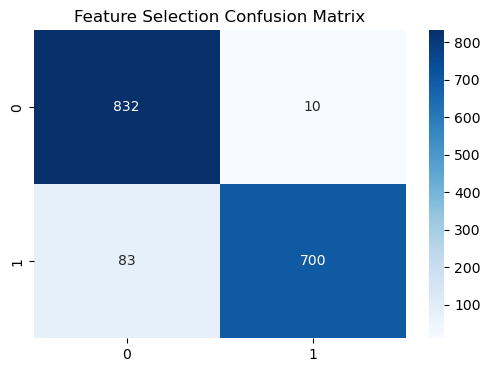


--- Feature Selection Model Evaluation (with a smaller value, retaining nearly the same accuarcy)---
Accuracy: 0.9421538461538461

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625



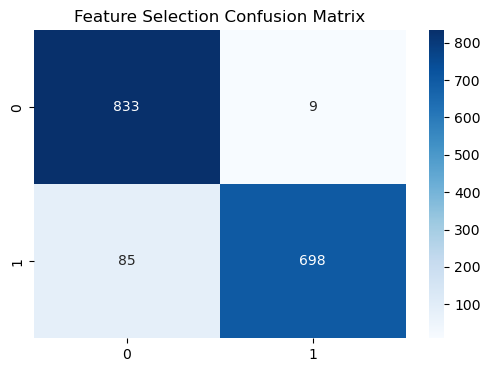

In [28]:
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap

k_scores = {}
for k in range(10,23):
    sk = SelectKBest(score_func = chi2, k = k) # based on the plot above
    X_train_trial = sk.fit_transform(X_train, y_train)
    X_validation_trial = sk.transform(X_validation)
    prior, likelihood = fit(X_train_trial, y_train)
    predictions = predict(X_validation_trial, prior, likelihood)
    k_scores[k] = accuracy_score(y_validation, predictions)

print(k_scores)

best_k = max(k_scores, key=k_scores.get)
near_best_k = 15
print(f"Best k: {best_k} with accuracy: {k_scores[best_k]}")

# Evaluate with best k
sk = SelectKBest(score_func=chi2, k=best_k)
X_train_best = sk.fit_transform(X_train, y_train)
X_validation_best = sk.transform(X_validation)
prior_best, likelihood_best = fit(X_train_best, y_train)
predictions_best = predict(X_validation_best, prior_best, likelihood_best)

print("\n--- Feature Selection Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_validation, predictions_best)}")
print("\nClassification Report:\n", classification_report(y_validation, predictions_best))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions_best), annot=True, fmt='d', cmap='Blues')
plt.title("Feature Selection Confusion Matrix")
plt.show()

# Evaluate with near_best k
sk = SelectKBest(score_func=chi2, k=near_best_k)
X_train_near_best = sk.fit_transform(X_train, y_train)
X_validation_near_best = sk.transform(X_validation)
prior_near_best, likelihood_near_best = fit(X_train_near_best, y_train)
predictions_near_best = predict(X_validation_near_best, prior_near_best, likelihood_near_best)

print("\n--- Feature Selection Model Evaluation (with a smaller value, retaining nearly the same accuarcy)---")
print(f"Accuracy: {accuracy_score(y_validation, predictions_near_best)}")
print("\nClassification Report:\n", classification_report(y_validation, predictions_near_best))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions_near_best), annot=True, fmt='d', cmap='Blues')
plt.title("Feature Selection Confusion Matrix")
plt.show()

# 5. Experiment B: PCA 📉

Cumulative Variance: [0.33432563 0.50582329 0.63086945 0.69843011 0.75779758 0.80834259
 0.85233841 0.89099977 0.92760753 0.95349226 0.97324724 0.98197189
 0.98723903 0.99128524 0.99448509 0.99647816 0.99794494 0.99922286
 0.99969597 0.99995002 1.         1.        ]


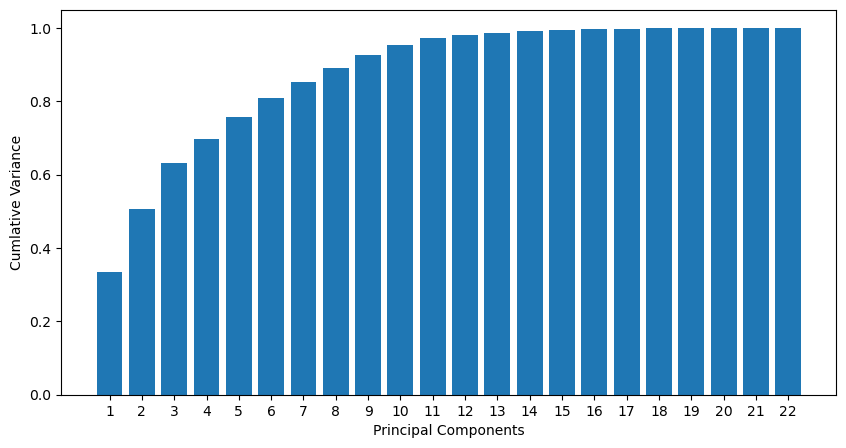


--- PCA Model Evaluation ---
Accuracy: 0.8910769230769231

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90       842
           1       0.91      0.86      0.88       783

    accuracy                           0.89      1625
   macro avg       0.89      0.89      0.89      1625
weighted avg       0.89      0.89      0.89      1625



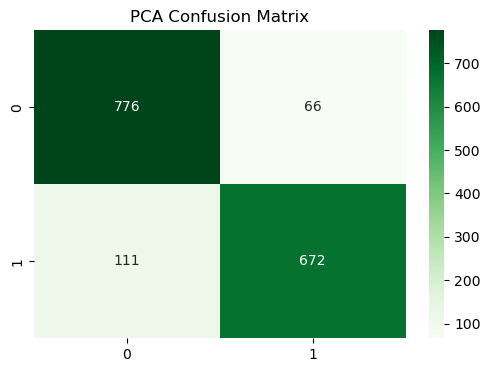

In [37]:
def PCA(X, k):
    shifted_x = X - np.mean(X, axis = 0)
    cov_mat = np.transpose(shifted_x) @ shifted_x * 1/ (shifted_x.shape[0] - 1)
    cov_mat = np.array(cov_mat)
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)
    dec_idx = np.argsort(eigen_values)[::-1]
    sorted_eigen_values = eigen_values[dec_idx]
    sorted_eigen_vectors = eigen_vectors[:, dec_idx]
    vectors_participation_percentage = sorted_eigen_values / sorted_eigen_values.sum()
    cum_variance = np.cumsum(vectors_participation_percentage)
    print("Cumulative Variance:", cum_variance)
    x_axis = range(1, len(cum_variance) + 1)
    plt.figure(figsize = (10,5))
    plt.bar(x_axis, cum_variance)
    plt.xlabel('Principal Components')
    plt.xticks(x_axis)
    plt.ylabel('Cumlative Variance')
    plt.show()
    top_k_vectors = sorted_eigen_vectors[:, :k]
    reduced_x = shifted_x @ top_k_vectors # feature vectors projectd on the new axis (principal components)
    return reduced_x, np.mean(X, axis = 0), top_k_vectors

def transform_pca(X, train_mean, train_vectors):
    shifted_X = X - train_mean
    reduced_X = shifted_X @ train_vectors
    return reduced_X

X_train_pca, train_mean, train_vectors = PCA(X_train,11) # best k = 11
X_validation_pca = transform_pca(X_validation, train_mean, train_vectors)
X_test_pca = transform_pca(X_test, train_mean, train_vectors)

X_train_pca_rounded = np.round(X_train_pca)
X_validation_pca_rounded = np.round(X_validation_pca)
X_test_pca_rounded = np.round(X_test_pca)

prior_pca, likelihood_pca = fit(X_train_pca_rounded, y_train)
predictions_pca = predict(X_validation_pca_rounded, prior_pca, likelihood_pca)

print("\n--- PCA Model Evaluation ---")
print("Accuracy:", accuracy_score(y_validation, predictions_pca))
print("\nClassification Report:\n", classification_report(y_validation, predictions_pca))

plt.figure(figsize=(6, 4))
heatmap(confusion_matrix(y_validation, predictions_pca), annot=True, fmt='d', cmap='Greens')
plt.title("PCA Confusion Matrix")
plt.show()

# 6. Comparative Analysis 🏆

--- Comparative Analysis Summary ---


,Model,Accuracy
0,Baseline (All Features),0.942769
1,Feature Selection (k=19),0.942769
2,PCA (k=7),0.891077


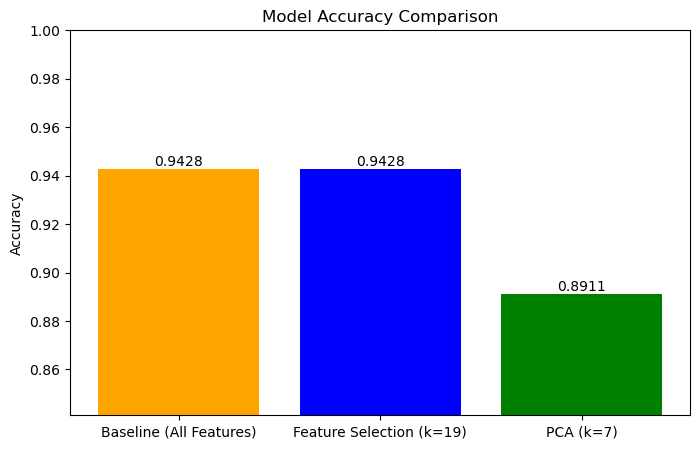

In [39]:
# Storing accuracies (ensure these variable names match those defined above)
# You might need to rerun the previous cells for this to work successfully.
# Baseline accuracy:
acc_baseline = accuracy_score(y_validation, predictions)
# Feature Selection accuracy:
acc_fs = accuracy_score(y_validation, predictions_best)
# PCA accuracy:
acc_pca = accuracy_score(y_validation, predictions_pca)

results_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', f'Feature Selection (k={best_k})', 'PCA (k=7)'],
    'Accuracy': [acc_baseline, acc_fs, acc_pca]
})

print("--- Comparative Analysis Summary ---")
display(results_df)

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=['orange', 'blue', 'green'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(min(results_df['Accuracy']) - 0.05, 1.0) # Zoom in for better visualization

# Add text on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.4f}", va='bottom', ha='center')

plt.show()